# 07 — Representation learning in motion on real digits 0–4

Representation learning is often described vaguely as “the network learns features.” Here we make it literal and visible.

We train a **64 → 2 → 5** network. Because the hidden layer has exactly two units, every real digit gets a 2D coordinate that we can plot at multiple epochs.

## What you should learn
- hidden activations are coordinates in a learned space;
- training moves samples in that space by changing weights;
- class structure emerges because the loss rewards geometry that makes the output classifier effective;
- a single sample's path can be tracked across epochs.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
d=load_digits();mask=d.target<5;X=d.data[mask]/16.0;y=d.target[mask].astype(int)
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)
K=5
Y=np.eye(K)[ytr]


In [2]:
rng=np.random.default_rng(4);W1=rng.normal(0,.15,(64,2));b1=np.zeros((1,2));W2=rng.normal(0,.15,(2,K));b2=np.zeros((1,K))
def softmax(z):
    z=z-z.max(1,keepdims=True);e=np.exp(z);return e/e.sum(1,keepdims=True)
def fwd(X_):
    z1=X_@W1+b1;h=np.tanh(z1);logits=h@W2+b2;p=softmax(logits);return z1,h,logits,p
save_epochs=[0,1,5,20,100,300,700];snap={};track=[];tracked=11;losses=[];lr=.8
for epoch in range(701):
    z1,h,logits,p=fwd(Xtr);loss=-np.mean(np.sum(Y*np.log(p+1e-9),axis=1));losses.append(loss)
    if epoch in save_epochs:snap[epoch]=h.copy()
    track.append(h[tracked].copy())
    dlog=(p-Y)/len(Xtr);dW2=h.T@dlog;db2=dlog.sum(0,keepdims=True);dh=dlog@W2.T;dz1=dh*(1-h**2);dW1=Xtr.T@dz1;db1=dz1.sum(0,keepdims=True)
    W2-=lr*dW2;b2-=lr*db2;W1-=lr*dW1;b1-=lr*db1
track=np.array(track)
print('final train CE:',losses[-1])


final train CE: 0.31422758223683245


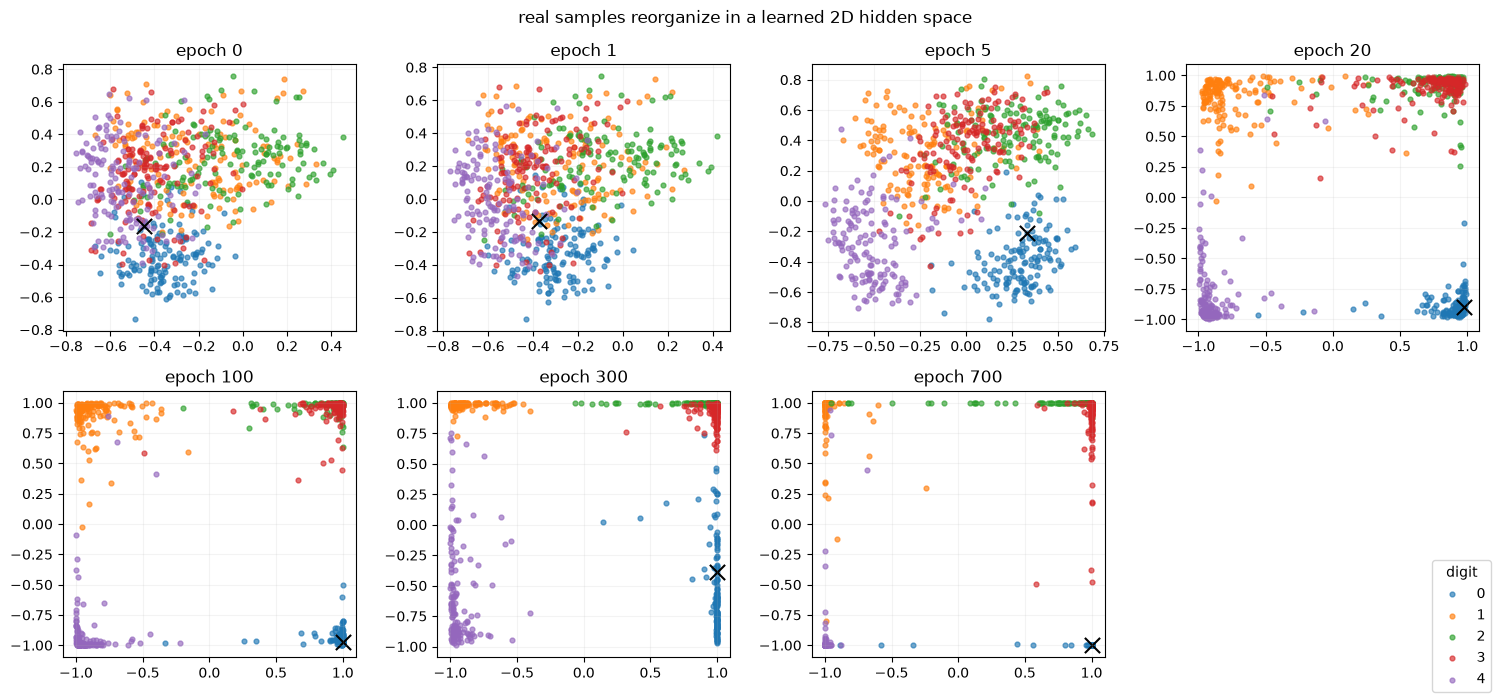

In [3]:
fig,axes=plt.subplots(2,4,figsize=(15,7));axes=axes.ravel()
for ax,ep in zip(axes,save_epochs):
    H=snap[ep]
    for cls in range(K):
        m=ytr==cls;ax.scatter(H[m,0],H[m,1],s=12,label=str(cls),alpha=.65)
    ax.scatter(H[tracked,0],H[tracked,1],s=120,marker='x',c='black');ax.set_title(f'epoch {ep}');ax.grid(alpha=.15)
axes[-1].axis('off');handles,labels_=axes[0].get_legend_handles_labels();fig.legend(handles,labels_,title='digit',loc='lower right')
fig.suptitle('real samples reorganize in a learned 2D hidden space');plt.tight_layout();plt.show()


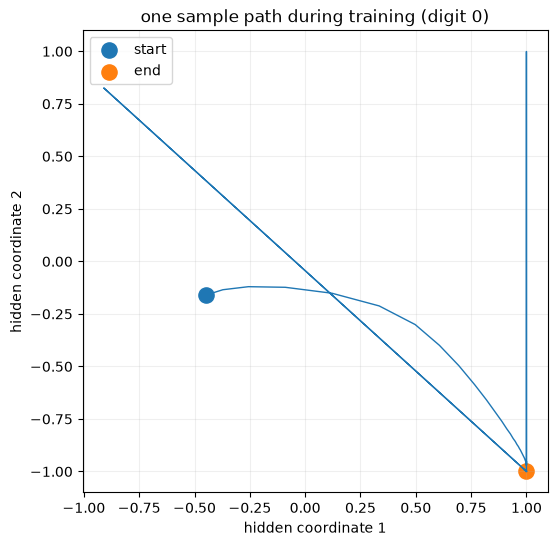

In [4]:
plt.figure(figsize=(6,6));plt.plot(track[:,0],track[:,1],lw=1);plt.scatter(*track[0],s=120,label='start');plt.scatter(*track[-1],s=120,label='end');
plt.xlabel('hidden coordinate 1');plt.ylabel('hidden coordinate 2');plt.title(f'one sample path during training (digit {ytr[tracked]})');plt.legend();plt.grid(alpha=.2);plt.show()


## Measure the geometry, not only look at it
A useful coarse statistic is the ratio of average distance between class centroids to average within-class spread. It is not a training objective here; it is a diagnostic for how separable the representation became.


In [5]:
def separation(H):
    cents=np.vstack([H[ytr==c].mean(0) for c in range(K)])
    between=np.mean([np.linalg.norm(cents[i]-cents[j]) for i in range(K) for j in range(i+1,K)])
    within=np.mean([np.linalg.norm(H[ytr==c]-cents[c],axis=1).mean() for c in range(K)])
    return between,within,between/(within+1e-9)
rows=[]
for ep in save_epochs:
    be,wi,ratio=separation(snap[ep]);rows.append([ep,be,wi,ratio])
pd.DataFrame(rows,columns=['epoch','between-centroid distance','within-class spread','separation ratio'])


,epoch,between-centroid distance,within-class spread,separation ratio
0,0,0.399698,0.243459,1.641743
1,1,0.377001,0.242855,1.552368
2,5,0.681919,0.251045,2.716318
3,20,1.698117,0.214442,7.918772
4,100,1.887973,0.129481,14.581038
5,300,1.739593,0.193690,8.981308
6,700,1.973792,0.137864,14.316940


## Inference / insight
Representation learning is **parameter learning viewed in data coordinates**. Weights change during backprop; therefore the same raw sample maps to a different hidden vector. Across many updates, the space warps so that the downstream linear output layer can solve the task more easily.
